In [ ]:
# import sys
# import subprocess

# print("=== 🖥️ 1. 시스템 및 그래픽카드 정보 (nvidia-smi) ===")
# try:
#     # 윈도우에 설치된 NVIDIA 드라이버 정보 출력
#     result = subprocess.run(['nvidia-smi'], stdout=subprocess.PIPE, text=True)
#     print(result.stdout)
# except FileNotFoundError:
#     print("⚠️ nvidia-smi 명령어를 찾을 수 없습니다. NVIDIA 드라이버가 없거나 환경변수에 등록되지 않았습니다.")

# print("\n=== 🧠 2. 현재 파이썬 및 파이토치 환경 ===")
# print(f"Python 실행 경로: {sys.executable}")
# print(f"Python 버전: {sys.version.split(' ')[0]}")

# try:
#     import torch
#     print(f"\nPyTorch 패키지 위치: {torch.__file__}")
#     print(f"PyTorch 버전: {torch.__version__}")
#     print(f"PyTorch 내장 CUDA 버전: {torch.version.cuda}")
#     print(f"CUDA (GPU) 활성화 여부: {torch.cuda.is_available()}")
    
#     if torch.cuda.is_available():
#         print(f"사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
#     else:
#         print("⚠️ 진단 결과: 현재 파이토치는 GPU를 인식하지 못하는 'CPU 전용 버전'입니다.")
# except ImportError:
#     print("\n⚠️ 현재 환경에 파이토치(torch)가 설치되어 있지 않습니다.")

### **쿠다 설치 위치 확인**
* 만약 쿠다 설치가 잘못되었다고 생각되면 위에 셀을 통해서 위치랑 실행 위치 확인하기
* 다시 설치후, VSCODE 재실행

In [1]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.

라이브러리 로드


<hr style="height: 5px; background-color: #39FF14; border: none;">

# **현재 RealSense 모든 설정 출력 코드 = 장치가 지원하는 전체 옵션**

In [1]:
import pyrealsense2 as rs
import json
from datetime import datetime
from pathlib import Path


def safe_call(fn, default=None):
    try:
        return fn()
    except Exception as e:
        return f"[ERROR] {type(e).__name__}: {e}" if default is None else default


def rs_info_name(info_enum):
    try:
        return str(info_enum).split(".")[-1]
    except Exception:
        return str(info_enum)


def rs_option_name(opt):
    try:
        return str(opt).split(".")[-1]
    except Exception:
        return str(opt)


def dump_realsense_all_settings(output_dir="realsense_settings_dump"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    ctx = rs.context()
    devices = ctx.query_devices()

    dump = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "device_count": len(devices),
        "devices": []
    }

    if len(devices) == 0:
        print("[ERROR] No RealSense device found.")
        return dump

    for dev_idx, dev in enumerate(devices):
        print(f"\n================ DEVICE {dev_idx} ================")

        dev_info = {}
        for info in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.recommended_firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
            rs.camera_info.usb_type_descriptor,
        ]:
            key = rs_info_name(info)
            if dev.supports(info):
                val = dev.get_info(info)
            else:
                val = None
            dev_info[key] = val
            print(f"{key:30s}: {val}")

        # Advanced mode JSON
        advanced_json = None
        try:
            adv = rs.rs400_advanced_mode(dev)
            adv_enabled = adv.is_enabled()
            dev_info["advanced_mode_enabled"] = adv_enabled
            print(f"{'advanced_mode_enabled':30s}: {adv_enabled}")

            if adv_enabled:
                advanced_json = adv.serialize_json()
                adv_path = output_dir / f"device_{dev_idx}_advanced_mode.json"
                adv_path.write_text(advanced_json, encoding="utf-8")
                print(f"[SAVE] Advanced mode JSON -> {adv_path}")
            else:
                print("[INFO] Advanced mode is disabled. Enable it in Viewer or with code if needed.")

        except Exception as e:
            dev_info["advanced_mode_error"] = f"{type(e).__name__}: {e}"
            print(f"[WARN] Advanced mode dump failed: {e}")

        sensors_dump = []

        for sensor_idx, sensor in enumerate(dev.query_sensors()):
            sensor_name = safe_call(lambda: sensor.get_info(rs.camera_info.name), f"sensor_{sensor_idx}")
            print(f"\n------------ SENSOR {sensor_idx}: {sensor_name} ------------")

            sensor_dump = {
                "sensor_index": sensor_idx,
                "sensor_name": sensor_name,
                "options": {},
                "stream_profiles": []
            }

            # sensor options
            supported_options = sensor.get_supported_options()

            for opt in supported_options:
                opt_key = rs_option_name(opt)

                opt_data = {
                    "current_value": None,
                    "description": None,
                    "range": None,
                    "value_descriptions": {}
                }

                opt_data["current_value"] = safe_call(lambda opt=opt: sensor.get_option(opt))
                opt_data["description"] = safe_call(lambda opt=opt: sensor.get_option_description(opt))

                rng = safe_call(lambda opt=opt: sensor.get_option_range(opt))
                if not isinstance(rng, str) and rng is not None:
                    opt_data["range"] = {
                        "min": rng.min,
                        "max": rng.max,
                        "step": rng.step,
                        "default": rng.default
                    }

                    # visual_preset 같은 enum형 option은 값 설명도 출력
                    if abs(rng.step - 1.0) < 1e-9 and (rng.max - rng.min) <= 30:
                        for v in range(int(rng.min), int(rng.max) + 1):
                            desc = safe_call(
                                lambda opt=opt, v=v: sensor.get_option_value_description(opt, float(v)),
                                default=""
                            )
                            if desc:
                                opt_data["value_descriptions"][str(v)] = desc

                sensor_dump["options"][opt_key] = opt_data

                cur = opt_data["current_value"]
                rr = opt_data["range"]
                descs = opt_data["value_descriptions"]

                if rr:
                    print(
                        f"{opt_key:35s} "
                        f"cur={cur} | min={rr['min']} max={rr['max']} "
                        f"step={rr['step']} default={rr['default']}"
                    )
                else:
                    print(f"{opt_key:35s} cur={cur}")

                if descs:
                    print("    value descriptions:")
                    for k, v in descs.items():
                        print(f"      {k}: {v}")

            # stream profiles
            print("\n[Stream Profiles]")
            profiles = safe_call(lambda: sensor.get_stream_profiles(), default=[])

            for p in profiles:
                p_info = {
                    "stream_type": str(p.stream_type()).split(".")[-1],
                    "format": str(p.format()).split(".")[-1],
                    "fps": p.fps(),
                    "is_video_profile": False
                }

                try:
                    vp = p.as_video_stream_profile()
                    p_info.update({
                        "is_video_profile": True,
                        "width": vp.width(),
                        "height": vp.height(),
                        "intrinsics": None
                    })

                    try:
                        intr = vp.get_intrinsics()
                        p_info["intrinsics"] = {
                            "width": intr.width,
                            "height": intr.height,
                            "fx": intr.fx,
                            "fy": intr.fy,
                            "ppx": intr.ppx,
                            "ppy": intr.ppy,
                            "model": str(intr.model),
                            "coeffs": list(intr.coeffs)
                        }
                    except Exception:
                        pass

                    print(
                        f"  {p_info['stream_type']:12s} "
                        f"{p_info['format']:8s} "
                        f"{p_info['width']}x{p_info['height']} @ {p_info['fps']}fps"
                    )

                except Exception:
                    print(
                        f"  {p_info['stream_type']:12s} "
                        f"{p_info['format']:8s} @ {p_info['fps']}fps"
                    )

                sensor_dump["stream_profiles"].append(p_info)

            sensors_dump.append(sensor_dump)

        dev_info["sensors"] = sensors_dump
        if advanced_json is not None:
            dev_info["advanced_mode_json_saved"] = str(output_dir / f"device_{dev_idx}_advanced_mode.json")

        dump["devices"].append(dev_info)

    out_path = output_dir / "realsense_all_settings.json"
    out_path.write_text(json.dumps(dump, indent=2, ensure_ascii=False), encoding="utf-8")

    print(f"\n================ DONE ================")
    print(f"[SAVE] All settings JSON -> {out_path}")

    return dump


settings = dump_realsense_all_settings()


================ DEVICE 0 ================
name                          : Intel RealSense D435IF
serial_number                 : 327122072783
firmware_version              : 5.17.0.10
recommended_firmware_version  : 5.17.0.10
physical_port                 : \\?\usb#vid_8086&pid_0b3a&mi_00#9&318fd29f&0&0000#{e5323777-f976-4f5b-9b55-b94699c46e44}\global
product_id                    : 0B3A
product_line                  : D400
usb_type_descriptor           : 3.2
advanced_mode_enabled         : True
[SAVE] Advanced mode JSON -> realsense_settings_dump\device_0_advanced_mode.json

------------ SENSOR 0: Stereo Module ------------
Exposure                            cur=80000.0 | min=1.0 max=165000.0 step=1.0 default=8500.0
Gain                                cur=16.0 | min=16.0 max=248.0 step=1.0 default=16.0
Enable Auto Exposure                cur=0.0 | min=0.0 max=1.0 step=1.0 default=1.0
Visual Preset                       cur=0.0 | min=0.0 max=5.0 step=1.0 default=0.0
    value descri

# **실제로 네가 켠 stream이 뭔지 확인**

In [7]:
import pyrealsense2 as rs
import json

pipeline = rs.pipeline()
config = rs.config()

# 네가 실제로 쓰는 설정으로 바꿔도 됨
config.enable_stream(rs.stream.depth, 848, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 848, 480, rs.format.bgr8, 30)

profile = pipeline.start(config)

try:
    print("\n[ACTIVE STREAMS]")
    for sp in profile.get_streams():
        vsp = sp.as_video_stream_profile()
        intr = vsp.get_intrinsics()

        print("--------------------------------")
        print("stream :", sp.stream_type())
        print("format :", sp.format())
        print("fps    :", sp.fps())
        print("size   :", vsp.width(), "x", vsp.height())
        print("fx, fy :", intr.fx, intr.fy)
        print("ppx,ppy:", intr.ppx, intr.ppy)
        print("model  :", intr.model)
        print("coeffs :", intr.coeffs)

    dev = profile.get_device()
    depth_sensor = dev.first_depth_sensor()

    print("\n[DEPTH SCALE]")
    print(depth_sensor.get_depth_scale())

    print("\n[DEPTH SENSOR CURRENT OPTIONS]")
    for opt in depth_sensor.get_supported_options():
        name = str(opt).split(".")[-1]
        val = depth_sensor.get_option(opt)
        print(f"{name:35s}: {val}")

finally:
    pipeline.stop()


[ACTIVE STREAMS]
--------------------------------
stream : stream.depth
format : format.z16
fps    : 30
size   : 848 x 480
fx, fy : 425.64202880859375 425.64202880859375
ppx,ppy: 429.978271484375 243.2578582763672
model  : distortion.brown_conrady
coeffs : [0.0, 0.0, 0.0, 0.0, 0.0]
--------------------------------
stream : stream.color
format : format.bgr8
fps    : 30
size   : 848 x 480
fx, fy : 606.1939697265625 606.0857543945312
ppx,ppy: 433.0955810546875 247.07073974609375
model  : distortion.inverse_brown_conrady
coeffs : [0.0, 0.0, 0.0, 0.0, 0.0]

[DEPTH SCALE]
9.999999747378752e-06

[DEPTH SENSOR CURRENT OPTIONS]
Exposure                           : 18103.0
Gain                               : 16.0
Enable Auto Exposure               : 1.0
Visual Preset                      : 0.0
Laser Power                        : 150.0
Emitter Enabled                    : 1.0
Frames Queue Size                  : 16.0
Asic Temperature                   : 47.0
Error Polling Enabled              

# **후처리 필터 설정값도 같이 출력하는 코드**

In [3]:
import pyrealsense2 as rs


def print_filter_options(filter_obj, name):
    print(f"\n========== FILTER: {name} ==========")

    for opt in filter_obj.get_supported_options():
        opt_name = str(opt).split(".")[-1]

        try:
            val = filter_obj.get_option(opt)
        except Exception as e:
            val = f"[ERROR] {e}"

        try:
            rng = filter_obj.get_option_range(opt)
            print(
                f"{opt_name:35s} "
                f"cur={val} | min={rng.min} max={rng.max} step={rng.step} default={rng.default}"
            )
        except Exception:
            print(f"{opt_name:35s} cur={val}")

        try:
            desc = filter_obj.get_option_description(opt)
            if desc:
                print(f"    desc: {desc}")
        except Exception:
            pass


decimation = rs.decimation_filter()
spatial = rs.spatial_filter()
temporal = rs.temporal_filter()
hole_filling = rs.hole_filling_filter()
disparity = rs.disparity_transform(True)
depth_back = rs.disparity_transform(False)

print_filter_options(decimation, "decimation_filter")
print_filter_options(spatial, "spatial_filter")
print_filter_options(temporal, "temporal_filter")
print_filter_options(hole_filling, "hole_filling_filter")
print_filter_options(disparity, "disparity_transform_true")
print_filter_options(depth_back, "disparity_transform_false")


========== FILTER: decimation_filter ==========
Frames Queue Size                   cur=16.0 | min=0.0 max=32.0 step=1.0 default=16.0
    desc: Max number of frames you can hold at a given time. Increasing this number will reduce frame drops but increase latency, and vice versa
Filter Magnitude                    cur=2.0 | min=1.0 max=8.0 step=1.0 default=2.0
    desc: Decimation scale
Stream Filter                       cur=1.0 | min=0.0 max=11.0 step=1.0 default=0.0
    desc: Stream type
Stream Format Filter                cur=1.0 | min=0.0 max=34.0 step=1.0 default=0.0
    desc: Stream format
Stream Index Filter                 cur=-1.0 | min=-1.0 max=16.0 step=1.0 default=-1.0
    desc: Stream index

========== FILTER: spatial_filter ==========
Frames Queue Size                   cur=16.0 | min=0.0 max=32.0 step=1.0 default=16.0
    desc: Max number of frames you can hold at a given time. Increasing this number will reduce frame drops but increase latency, and vice versa
Filter Ma

# **센서 설정**

In [4]:
import pyrealsense2 as rs

decimation = rs.decimation_filter()
spatial = rs.spatial_filter()
temporal = rs.temporal_filter()
hole_filling = rs.hole_filling_filter()

disparity = rs.disparity_transform(True)
depth_back = rs.disparity_transform(False)

# Decimation
decimation.set_option(rs.option.filter_magnitude, 1)
# 1: 거의 원본 유지
# 2: 계산량 감소 + 약간 안정화

# Spatial Filter - 직각 보존용 약한 설정
spatial.set_option(rs.option.filter_magnitude, 1)
spatial.set_option(rs.option.filter_smooth_alpha, 0.75)
spatial.set_option(rs.option.filter_smooth_delta, 12)
spatial.set_option(rs.option.holes_fill, 0)

# Temporal Filter
temporal.set_option(rs.option.filter_smooth_alpha, 0.4)
temporal.set_option(rs.option.filter_smooth_delta, 20)

# persistence_control이 지원되는 경우에만
try:
    temporal.set_option(rs.option.persistence_control, 0)
except Exception:
    pass

# Hole filling은 처음에는 아예 빼고 테스트 추천
use_hole_filling = False


def process_depth_frame(depth_frame):
    frame = depth_frame

    frame = decimation.process(frame)
    frame = disparity.process(frame)
    frame = spatial.process(frame)
    frame = temporal.process(frame)
    frame = depth_back.process(frame)

    if use_hole_filling:
        frame = hole_filling.process(frame)

    return frame

---

# **시작**

In [61]:
import pyrealsense2 as rs
import numpy as np
import cv2
import matplotlib.pyplot as plt
import json
from pathlib import Path
import time
import pprint


# ============================================================
# 0. 사용자 설정
# ============================================================

CONFIG = {
    # RealSense Viewer에서 저장한 Advanced Mode JSON 경로
    # 사용하지 않으려면 None
    # "advanced_json_path": None,
    # 예: "camset.json"
    # "advanced_json_path": "camset.json",
    "advanced_json_path": "view_short.json",

    # 스트림 설정
    "depth_width": 848,
    "depth_height": 480,
    "depth_fps": 30,

    # color는 BGR8 640x480이 가장 무난함
    # align_to_color를 하면 aligned_depth도 color 해상도인 640x480이 됨
    "color_width": 640,
    "color_height": 480,
    "color_fps": 30,

    # 카메라 직접 설정
    "use_depth_auto_exposure": True,
    "depth_exposure_us": 18000,   # auto exposure OFF일 때만 의미 있음
    "depth_gain": 16,

    "emitter_enabled": 1,         # 0=off, 1=laser on, 2=auto
    "laser_power": 150,

    # Depth Units
    # 0.001   = 1mm/count, 기본 안정값
    # 0.0001  = 0.1mm/count, 근거리 타협값
    # 0.00001 = 0.01mm/count, 65cm 근거리 강제 느낌
    "depth_units_m": 0.00001,

    # ROI 기반 Auto Exposure 영역
    # depth stream 기준 픽셀 좌표
    # None이면 중앙 ROI 자동 생성
    "depth_ae_roi": None,
    # 예:
    # "depth_ae_roi": {"min_x": 180, "min_y": 120, "max_x": 680, "max_y": 420},

    # 중앙 ROI 비율
    "roi_ratio_x": 0.55,
    "roi_ratio_y": 0.65,

    # Color 설정
    "use_color_auto_exposure": True,
    "use_color_auto_white_balance": True,

    # Pre-process filter ON/OFF
    "enable_threshold": True,
    "threshold_min_m": 0.15,
    "threshold_max_m": 0.60,

    "enable_disparity_spatial": False,
    "enable_temporal": False,
    "enable_hole_filling": True,

    # Spatial Filter 설정
    # 직각/얇은 엣지 보존 목적이면 약하게
    "spatial_magnitude": 1,
    "spatial_alpha": 0.85,
    "spatial_delta": 8,
    "spatial_holes_fill": 0,

    # Temporal Filter 설정
    "temporal_alpha": 0.7,
    "temporal_delta": 10,
    "temporal_persistency": 0,

    # Hole Filling 설정
    # 0,1,2 중 선택. 보통 1부터
    "hole_filling_mode": 1,

    # warmup frame
    "warmup_frames": 30,
}


def print_title(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def set_option_if_supported(sensor, option, value, name=None):
    name = name or str(option)
    try:
        if sensor.supports(option):
            sensor.set_option(option, float(value))
            print(f"[SET] {name}: {value}")
        else:
            print(f"[SKIP] {name}: not supported")
    except Exception as e:
        print(f"[ERROR] {name}: {e}")


def get_sensor_by_name(device, keyword):
    keyword = keyword.lower()
    for sensor in device.query_sensors():
        try:
            name = sensor.get_info(rs.camera_info.name).lower()
        except Exception:
            name = ""
        if keyword in name:
            return sensor
    return None


def make_center_roi(width, height, ratio_x=0.55, ratio_y=0.65):
    roi_w = int(width * ratio_x)
    roi_h = int(height * ratio_y)
    x0 = (width - roi_w) // 2
    y0 = (height - roi_h) // 2
    x1 = x0 + roi_w
    y1 = y0 + roi_h
    return {
        "min_x": x0,
        "min_y": y0,
        "max_x": x1,
        "max_y": y1,
    }


def clean_advanced_json_for_device(json_path):
    """
    RealSense Viewer 저장 JSON 중 device/parameters/schema version만 남긴다.
    filters, viewer 같은 키가 있으면 rs2_load_json에서 에러날 수 있음.
    """
    json_path = Path(json_path)
    data = json.loads(json_path.read_text(encoding="utf-8"))

    cleaned = {}
    if "device" in data:
        cleaned["device"] = data["device"]
    if "parameters" in data:
        cleaned["parameters"] = data["parameters"]
    if "schema version" in data:
        cleaned["schema version"] = data["schema version"]
    else:
        cleaned["schema version"] = 1

    return json.dumps(cleaned, indent=4)


def intrinsics_to_dict(intr):
    return {
        "width": intr.width,
        "height": intr.height,
        "fx": intr.fx,
        "fy": intr.fy,
        "ppx": intr.ppx,
        "ppy": intr.ppy,
        "model": str(intr.model),
        "coeffs": list(intr.coeffs),
    }

In [62]:
# ============================================================
# 1. 카메라 시작 및 설정 적용
# ============================================================

print_title("START REALSENSE")

pipeline = rs.pipeline()
config = rs.config()

config.enable_stream(
    rs.stream.depth,
    CONFIG["depth_width"],
    CONFIG["depth_height"],
    rs.format.z16,
    CONFIG["depth_fps"],
)

config.enable_stream(
    rs.stream.color,
    CONFIG["color_width"],
    CONFIG["color_height"],
    rs.format.bgr8,
    CONFIG["color_fps"],
)

# ------------------------------------------------------------
# Advanced JSON 로드
# pipeline start 전에 장치에 직접 로드
# ------------------------------------------------------------
ctx = rs.context()
devices = ctx.query_devices()

if len(devices) == 0:
    raise RuntimeError("RealSense device not found.")

device_for_json = devices[0]

if CONFIG["advanced_json_path"] is not None:
    json_path = Path(CONFIG["advanced_json_path"])
    if json_path.exists():
        print(f"[LOAD JSON] {json_path}")
        adv = rs.rs400_advanced_mode(device_for_json)
        cleaned_json = clean_advanced_json_for_device(json_path)
        adv.load_json(cleaned_json)
        time.sleep(1.0)
        print("[OK] Advanced Mode JSON loaded.")
    else:
        print(f"[WARN] JSON path not found: {json_path}")

# ------------------------------------------------------------
# pipeline start
# ------------------------------------------------------------
profile = pipeline.start(config)
device = profile.get_device()

depth_sensor = device.first_depth_sensor()
stereo_sensor = get_sensor_by_name(device, "stereo")
color_sensor = get_sensor_by_name(device, "rgb")

if stereo_sensor is None:
    stereo_sensor = depth_sensor

print("\n[DEVICE INFO]")
for info in [
    rs.camera_info.name,
    rs.camera_info.serial_number,
    rs.camera_info.firmware_version,
    rs.camera_info.usb_type_descriptor,
]:
    if device.supports(info):
        print(f"{str(info):35s}: {device.get_info(info)}")

# ------------------------------------------------------------
# Depth 카메라 직접 설정
# ------------------------------------------------------------
print_title("APPLY DEPTH CAMERA SETTINGS")

set_option_if_supported(
    depth_sensor,
    rs.option.enable_auto_exposure,
    1 if CONFIG["use_depth_auto_exposure"] else 0,
    "depth enable_auto_exposure",
)

if not CONFIG["use_depth_auto_exposure"]:
    set_option_if_supported(
        depth_sensor,
        rs.option.exposure,
        CONFIG["depth_exposure_us"],
        "depth exposure_us",
    )

set_option_if_supported(
    depth_sensor,
    rs.option.gain,
    CONFIG["depth_gain"],
    "depth gain",
)

set_option_if_supported(
    depth_sensor,
    rs.option.emitter_enabled,
    CONFIG["emitter_enabled"],
    "emitter_enabled",
)

set_option_if_supported(
    depth_sensor,
    rs.option.laser_power,
    CONFIG["laser_power"],
    "laser_power",
)

set_option_if_supported(
    depth_sensor,
    rs.option.depth_units,
    CONFIG["depth_units_m"],
    "depth_units_m",
)

# ------------------------------------------------------------
# ROI 기반 Auto Exposure 설정
# ------------------------------------------------------------
print_title("APPLY DEPTH AUTO EXPOSURE ROI")

depth_roi = CONFIG["depth_ae_roi"]

if depth_roi is None:
    depth_roi = make_center_roi(
        CONFIG["depth_width"],
        CONFIG["depth_height"],
        CONFIG["roi_ratio_x"],
        CONFIG["roi_ratio_y"],
    )

print("[ROI]", depth_roi)

try:
    roi_sensor = stereo_sensor.as_roi_sensor()

    roi = rs.region_of_interest()
    roi.min_x = int(depth_roi["min_x"])
    roi.min_y = int(depth_roi["min_y"])
    roi.max_x = int(depth_roi["max_x"])
    roi.max_y = int(depth_roi["max_y"])

    roi_sensor.set_region_of_interest(roi)
    print("[OK] Depth Auto Exposure ROI applied.")

except Exception as e:
    print("[WARN] ROI setting failed.")
    print(e)

# ------------------------------------------------------------
# Color 설정
# 화이트밸런스는 자동 유지
# ------------------------------------------------------------
print_title("APPLY COLOR SETTINGS")

if color_sensor is not None:
    set_option_if_supported(
        color_sensor,
        rs.option.enable_auto_exposure,
        1 if CONFIG["use_color_auto_exposure"] else 0,
        "color enable_auto_exposure",
    )

    set_option_if_supported(
        color_sensor,
        rs.option.enable_auto_white_balance,
        1 if CONFIG["use_color_auto_white_balance"] else 0,
        "color enable_auto_white_balance",
    )
else:
    print("[WARN] RGB sensor not found.")

# ------------------------------------------------------------
# Align 객체
# color 기준으로 depth align
# 결과 aligned_depth shape는 color 해상도와 같아짐
# ------------------------------------------------------------
align_to_color = rs.align(rs.stream.color)

# ------------------------------------------------------------
# Pre-process filter 객체 생성
# ------------------------------------------------------------
print_title("CREATE PREPROCESS FILTERS")

threshold_filter = rs.threshold_filter()
threshold_filter.set_option(rs.option.min_distance, CONFIG["threshold_min_m"])
threshold_filter.set_option(rs.option.max_distance, CONFIG["threshold_max_m"])

spatial_filter = rs.spatial_filter()
spatial_filter.set_option(rs.option.filter_magnitude, CONFIG["spatial_magnitude"])
spatial_filter.set_option(rs.option.filter_smooth_alpha, CONFIG["spatial_alpha"])
spatial_filter.set_option(rs.option.filter_smooth_delta, CONFIG["spatial_delta"])
spatial_filter.set_option(rs.option.holes_fill, CONFIG["spatial_holes_fill"])

temporal_filter = rs.temporal_filter()
temporal_filter.set_option(rs.option.filter_smooth_alpha, CONFIG["temporal_alpha"])
temporal_filter.set_option(rs.option.filter_smooth_delta, CONFIG["temporal_delta"])
temporal_filter.set_option(rs.option.holes_fill, CONFIG["temporal_persistency"])

hole_filling_filter = rs.hole_filling_filter()
hole_filling_filter.set_option(rs.option.holes_fill, CONFIG["hole_filling_mode"])

disparity_transform = rs.disparity_transform(True)
depth_transform = rs.disparity_transform(False)


def preprocess_depth_frame(depth_frame):
    """
    aligned_depth_frame을 입력받아 threshold / spatial / temporal / hole filling 적용.
    직각/외곽 검출 목적이면 spatial, temporal, hole filling은 약하게 쓰거나 OFF 추천.
    """
    frame = depth_frame

    if CONFIG["enable_threshold"]:
        frame = threshold_filter.process(frame)

    if CONFIG["enable_disparity_spatial"]:
        frame = disparity_transform.process(frame)
        frame = spatial_filter.process(frame)
        frame = depth_transform.process(frame)

    if CONFIG["enable_temporal"]:
        frame = temporal_filter.process(frame)

    if CONFIG["enable_hole_filling"]:
        frame = hole_filling_filter.process(frame)

    return frame


# ------------------------------------------------------------
# 현재 적용값 확인
# ------------------------------------------------------------
print_title("CURRENT SENSOR OPTIONS")

print("[DEPTH SCALE]", depth_sensor.get_depth_scale())

for opt, name in [
    (rs.option.enable_auto_exposure, "depth enable_auto_exposure"),
    (rs.option.exposure, "depth exposure"),
    (rs.option.gain, "depth gain"),
    (rs.option.emitter_enabled, "emitter_enabled"),
    (rs.option.laser_power, "laser_power"),
    (rs.option.depth_units, "depth_units"),
]:
    if depth_sensor.supports(opt):
        try:
            print(f"{name:35s}: {depth_sensor.get_option(opt)}")
        except Exception as e:
            print(f"{name:35s}: {e}")

print("\n[WARMUP]")
for _ in range(CONFIG["warmup_frames"]):
    pipeline.wait_for_frames()

print("[OK] Camera ready.")


START REALSENSE
[WARN] JSON path not found: view_short.json

[DEVICE INFO]
camera_info.name                   : Intel RealSense D435IF
camera_info.serial_number          : 327122072783
camera_info.firmware_version       : 5.17.0.10
camera_info.usb_type_descriptor    : 3.2

APPLY DEPTH CAMERA SETTINGS
[SET] depth enable_auto_exposure: 1
[SET] depth gain: 16
[SET] emitter_enabled: 1
[SET] laser_power: 150
[SET] depth_units_m: 1e-05

APPLY DEPTH AUTO EXPOSURE ROI
[ROI] {'min_x': 191, 'min_y': 84, 'max_x': 657, 'max_y': 396}
[OK] Depth Auto Exposure ROI applied.

APPLY COLOR SETTINGS
[SET] color enable_auto_exposure: 1
[SET] color enable_auto_white_balance: 1

CREATE PREPROCESS FILTERS

CURRENT SENSOR OPTIONS
[DEPTH SCALE] 9.999999747378752e-06
depth enable_auto_exposure         : 0.0
depth exposure                     : 18103.0
depth gain                         : 16.0
emitter_enabled                    : 1.0
laser_power                        : 150.0
depth_units                        :


CAPTURE ALIGNED FRAME
color_img shape             : (480, 640, 3) uint8
aligned_depth_raw shape     : (480, 640) uint16
aligned_depth_processed shape: (480, 640) uint16
depth_scale                 : 9.999999747378752e-06

INTRINSICS
{'aligned_to': 'color',
 'color_intrinsics_for_aligned_depth': {'width': 640,
                                        'height': 480,
                                        'fx': 606.1939697265625,
                                        'fy': 606.0857543945312,
                                        'ppx': 329.0955810546875,
                                        'ppy': 247.07073974609375,
                                        'model': 'distortion.inverse_brown_conrady',
                                        'coeffs': [0.0, 0.0, 0.0, 0.0, 0.0]},
 'raw_depth_intrinsics': {'width': 848,
                          'height': 480,
                          'fx': 425.64202880859375,
                          'fy': 425.64202880859375,
                      

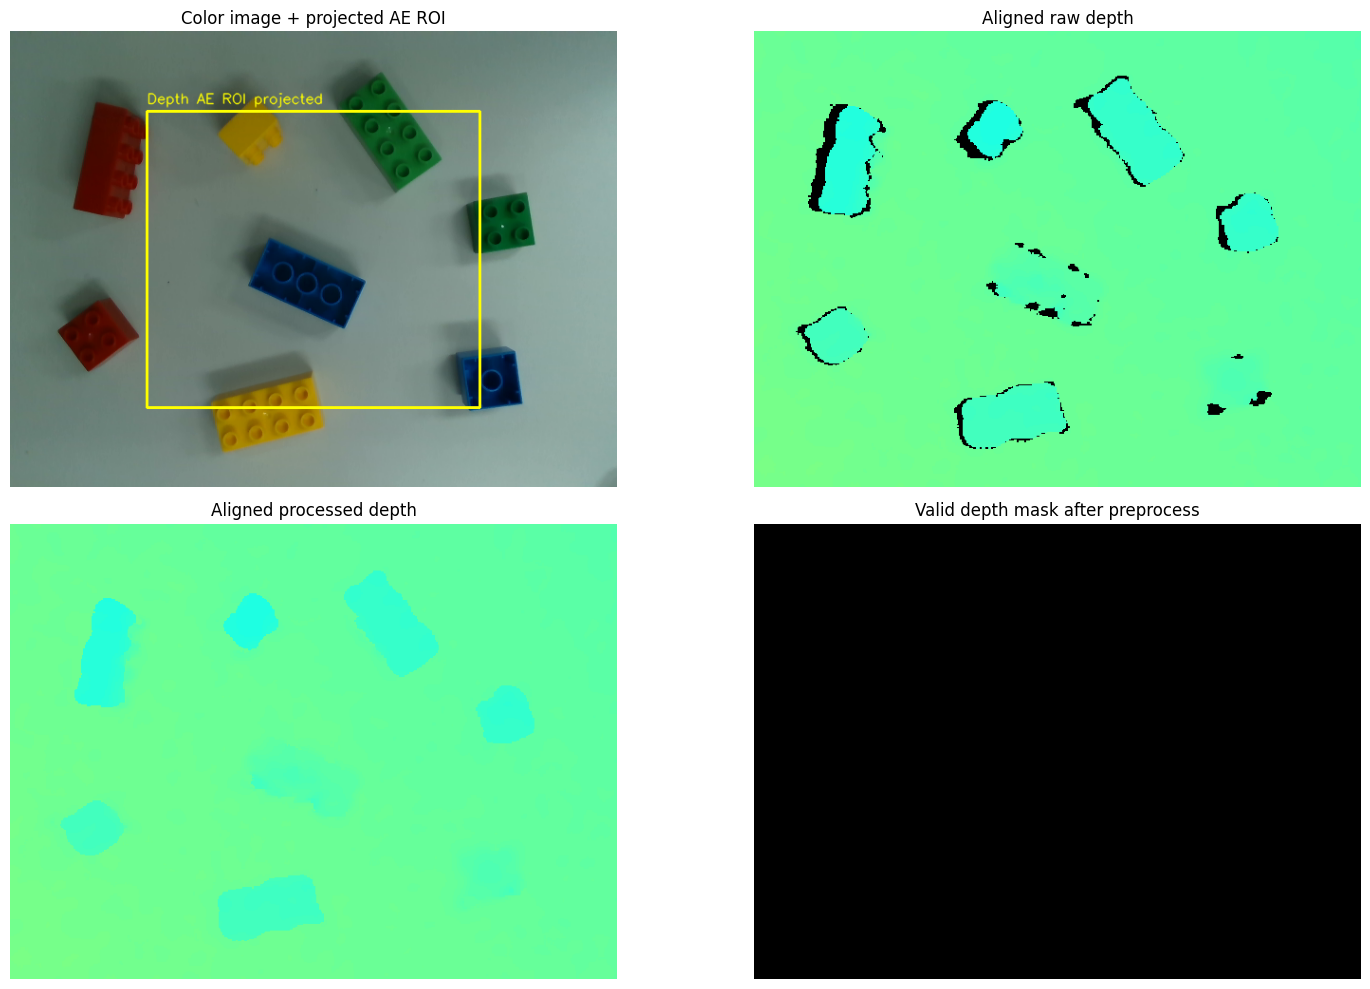

[OK] rs_output 변수에 color/depth/intrinsics 저장됨.


In [63]:
# ============================================================
# 2. 프레임 획득 + aligned depth/color + intrinsics 출력
# ============================================================

print_title("CAPTURE ALIGNED FRAME")

frames = pipeline.wait_for_frames()
aligned_frames = align_to_color.process(frames)

aligned_depth_frame_raw = aligned_frames.get_depth_frame()
color_frame = aligned_frames.get_color_frame()

if not aligned_depth_frame_raw:
    raise RuntimeError("No aligned depth frame.")
if not color_frame:
    raise RuntimeError("No color frame.")

# pre-process 적용된 aligned depth
aligned_depth_frame = preprocess_depth_frame(aligned_depth_frame_raw)

aligned_depth_img = np.asanyarray(aligned_depth_frame.get_data())
aligned_depth_raw_img = np.asanyarray(aligned_depth_frame_raw.get_data())
color_img = np.asanyarray(color_frame.get_data())

depth_scale = depth_sensor.get_depth_scale()
aligned_depth_m = aligned_depth_img.astype(np.float32) * depth_scale
aligned_depth_raw_m = aligned_depth_raw_img.astype(np.float32) * depth_scale

print("color_img shape             :", color_img.shape, color_img.dtype)
print("aligned_depth_raw shape     :", aligned_depth_raw_img.shape, aligned_depth_raw_img.dtype)
print("aligned_depth_processed shape:", aligned_depth_img.shape, aligned_depth_img.dtype)
print("depth_scale                 :", depth_scale)

# ------------------------------------------------------------
# Intrinsics
# aligned_depth는 color 좌표계로 align 되었으므로
# aligned_depth 픽셀을 3D로 deproject할 때는 color intrinsics를 쓰는 게 맞음
# ------------------------------------------------------------
color_profile = color_frame.profile.as_video_stream_profile()
color_intr = color_profile.get_intrinsics()

raw_depth_profile = profile.get_stream(rs.stream.depth).as_video_stream_profile()
raw_depth_intr = raw_depth_profile.get_intrinsics()

intrinsics = {
    "aligned_to": "color",
    "color_intrinsics_for_aligned_depth": intrinsics_to_dict(color_intr),
    "raw_depth_intrinsics": intrinsics_to_dict(raw_depth_intr),
    "depth_scale": depth_scale,
    "depth_units_option": depth_sensor.get_option(rs.option.depth_units)
        if depth_sensor.supports(rs.option.depth_units) else None,
    "depth_ae_roi": depth_roi,
    "preprocess_config": {
        "threshold": {
            "enabled": CONFIG["enable_threshold"],
            "min_m": CONFIG["threshold_min_m"],
            "max_m": CONFIG["threshold_max_m"],
        },
        "disparity_spatial": {
            "enabled": CONFIG["enable_disparity_spatial"],
            "spatial_magnitude": CONFIG["spatial_magnitude"],
            "spatial_alpha": CONFIG["spatial_alpha"],
            "spatial_delta": CONFIG["spatial_delta"],
            "spatial_holes_fill": CONFIG["spatial_holes_fill"],
        },
        "temporal": {
            "enabled": CONFIG["enable_temporal"],
            "temporal_alpha": CONFIG["temporal_alpha"],
            "temporal_delta": CONFIG["temporal_delta"],
            "temporal_persistency": CONFIG["temporal_persistency"],
        },
        "hole_filling": {
            "enabled": CONFIG["enable_hole_filling"],
            "mode": CONFIG["hole_filling_mode"],
        },
    },
}

print_title("INTRINSICS")
pprint.pprint(intrinsics, sort_dicts=False)

# ------------------------------------------------------------
# Depth visualization
# ------------------------------------------------------------
def colorize_depth_for_view(depth_m, min_m=None, max_m=None):
    valid = depth_m > 0

    if min_m is None:
        min_m = CONFIG["threshold_min_m"]

    if max_m is None:
        max_m = CONFIG["threshold_max_m"]

    vis = np.zeros(depth_m.shape, dtype=np.uint8)
    valid_range = valid & (depth_m >= min_m) & (depth_m <= max_m)

    clipped = np.clip(depth_m, min_m, max_m)
    vis[valid_range] = (
        (clipped[valid_range] - min_m) / (max_m - min_m + 1e-9) * 255
    ).astype(np.uint8)

    colorized = cv2.applyColorMap(vis, cv2.COLORMAP_JET)
    colorized[~valid_range] = 0
    return colorized


depth_raw_vis = colorize_depth_for_view(
    aligned_depth_raw_m,
    CONFIG["threshold_min_m"],
    CONFIG["threshold_max_m"],
)

depth_proc_vis = colorize_depth_for_view(
    aligned_depth_m,
    CONFIG["threshold_min_m"],
    CONFIG["threshold_max_m"],
)

# ROI 표시: depth ROI는 raw depth 기준이라 color aligned 화면과 해상도가 다를 수 있음.
# 여기서는 color 화면 중앙에 참고용으로 비율 변환해서 표시.
color_vis = color_img.copy()

sx = CONFIG["color_width"] / CONFIG["depth_width"]
sy = CONFIG["color_height"] / CONFIG["depth_height"]

rx0 = int(depth_roi["min_x"] * sx)
ry0 = int(depth_roi["min_y"] * sy)
rx1 = int(depth_roi["max_x"] * sx)
ry1 = int(depth_roi["max_y"] * sy)

cv2.rectangle(color_vis, (rx0, ry0), (rx1, ry1), (0, 255, 255), 2)
cv2.putText(
    color_vis,
    "Depth AE ROI projected",
    (rx0, max(20, ry0 - 8)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.5,
    (0, 255, 255),
    1,
    cv2.LINE_AA,
)

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(color_vis, cv2.COLOR_BGR2RGB))
plt.title("Color image + projected AE ROI")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(depth_raw_vis, cv2.COLOR_BGR2RGB))
plt.title("Aligned raw depth")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(depth_proc_vis, cv2.COLOR_BGR2RGB))
plt.title("Aligned processed depth")
plt.axis("off")

plt.subplot(2, 2, 4)
valid_mask = (aligned_depth_m > 0).astype(np.uint8) * 255
plt.imshow(valid_mask, cmap="gray")
plt.title("Valid depth mask after preprocess")
plt.axis("off")

plt.tight_layout()
plt.show()


# 이후 다른 셀에서 쓸 수 있게 변수 유지
rs_output = {
    "color_img_bgr": color_img,
    "aligned_depth_raw_uint16": aligned_depth_raw_img,
    "aligned_depth_processed_uint16": aligned_depth_img,
    "aligned_depth_raw_m": aligned_depth_raw_m,
    "aligned_depth_processed_m": aligned_depth_m,
    "intrinsics": intrinsics,
    "depth_scale": depth_scale,
}

print("[OK] rs_output 변수에 color/depth/intrinsics 저장됨.")

In [31]:
pipeline.stop()
print("RealSense stopped.")

RealSense stopped.


In [56]:
color_img_bgr = rs_output["color_img_bgr"]
aligned_depth_img = rs_output["aligned_depth_processed_uint16"]


라이브러리 로드

0: 480x640 1 2x2_blue, 1 2x2_green, 2 2x2_reds, 1 2x2_yellow, 1 4x2_blue, 2 4x2_greens, 1 4x2_yellow, 12.8ms
Speed: 23.7ms preprocess, 12.8ms inference, 3.8ms postprocess per image at shape (1, 3, 480, 640)
[INFO] original bbox 개수: 9
[INFO] merged bbox 개수: 9
[SUCCESS] merged bbox 9개를 mask로 변환 완료


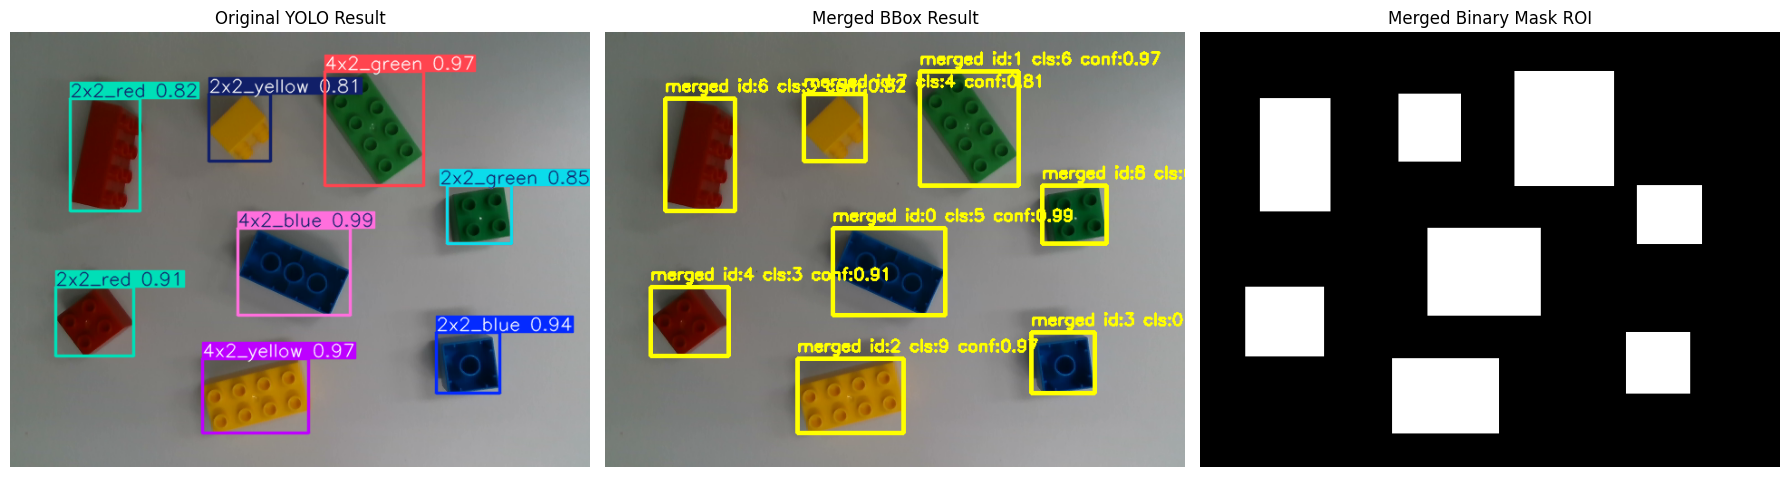

In [57]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

# import INUVisionLib as ivl

print("\n라이브러리 로드")

# ---------------------------------------------------------
# 1. YOLO 모델 로드
# ---------------------------------------------------------
model = YOLO("../yolo_models/train1_05_04/weights/best.pt")

target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

H, W = color_img_bgr.shape[:2]

# ---------------------------------------------------------
# 2. YOLO 추론
# ---------------------------------------------------------
results = model(color_img_bgr, classes=target_classes)

# ---------------------------------------------------------
# 2-1. 같은 class ID bbox 병합 함수
# ---------------------------------------------------------
def boxes_are_close_or_overlap(box_a, box_b, margin=10):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ax1 -= margin
    ay1 -= margin
    ax2 += margin
    ay2 += margin

    if ax2 < bx1:
        return False
    if bx2 < ax1:
        return False
    if ay2 < by1:
        return False
    if by2 < ay1:
        return False

    return True


def merge_close_boxes_by_class(boxes, clss, confs=None, margin=10):
    boxes = np.asarray(boxes, dtype=np.float32)
    clss = np.asarray(clss, dtype=np.int32)

    if confs is None:
        confs = np.ones(len(boxes), dtype=np.float32)
    else:
        confs = np.asarray(confs, dtype=np.float32)

    n = len(boxes)
    if n == 0:
        return boxes, clss, confs

    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra != rb:
            parent[rb] = ra

    for i in range(n):
        for j in range(i + 1, n):
            if clss[i] != clss[j]:
                continue

            if boxes_are_close_or_overlap(boxes[i], boxes[j], margin=margin):
                union(i, j)

    groups = {}
    for i in range(n):
        root = find(i)
        groups.setdefault(root, []).append(i)

    merged_boxes = []
    merged_clss = []
    merged_confs = []

    for _, idxs in groups.items():
        group_boxes = boxes[idxs]
        group_confs = confs[idxs]
        group_clss = clss[idxs]

        x1 = np.min(group_boxes[:, 0])
        y1 = np.min(group_boxes[:, 1])
        x2 = np.max(group_boxes[:, 2])
        y2 = np.max(group_boxes[:, 3])

        cls = int(group_clss[0])
        conf = float(np.max(group_confs))

        x1 = max(0, min(x1, W - 1))
        y1 = max(0, min(y1, H - 1))
        x2 = max(0, min(x2, W - 1))
        y2 = max(0, min(y2, H - 1))

        merged_boxes.append([x1, y1, x2, y2])
        merged_clss.append(cls)
        merged_confs.append(conf)

    return (
        np.asarray(merged_boxes, dtype=np.float32),
        np.asarray(merged_clss, dtype=np.int32),
        np.asarray(merged_confs, dtype=np.float32)
    )


# ---------------------------------------------------------
# 3. YOLO 결과에서 bbox 추출 후 병합
# ---------------------------------------------------------
mask_binary = np.zeros((H, W), dtype=np.uint8)

merged_boxes = np.empty((0, 4), dtype=np.float32)
merged_clss = np.empty((0,), dtype=np.int32)
merged_confs = np.empty((0,), dtype=np.float32)

if len(results) > 0:
    r = results[0]

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy()
        clss = r.boxes.cls.cpu().numpy().astype(int)

        if r.boxes.conf is not None:
            confs = r.boxes.conf.cpu().numpy()
        else:
            confs = np.ones(len(boxes), dtype=np.float32)

        merged_boxes, merged_clss, merged_confs = merge_close_boxes_by_class(
            boxes=boxes,
            clss=clss,
            confs=confs,
            margin=10
        )

        print(f"[INFO] original bbox 개수: {len(boxes)}")
        print(f"[INFO] merged bbox 개수: {len(merged_boxes)}")

        # 병합된 bbox로 mask 생성
        for box in merged_boxes:
            x1, y1, x2, y2 = box.astype(int)

            x1 = max(0, min(x1, W - 1))
            y1 = max(0, min(y1, H - 1))
            x2 = max(0, min(x2, W - 1))
            y2 = max(0, min(y2, H - 1))

            mask_binary[y1:y2 + 1, x1:x2 + 1] = 1

        print(f"[SUCCESS] merged bbox {len(merged_boxes)}개를 mask로 변환 완료")

    else:
        print("[WARN] 지정된 클래스의 객체가 검출되지 않았습니다.")

else:
    print("[WARN] YOLO result가 비어 있습니다.")


# ---------------------------------------------------------
# 4. 시각화
# ---------------------------------------------------------
vis_original = results[0].plot() if len(results) > 0 else color_img_bgr.copy()
vis_merged = color_img_bgr.copy()

# 병합 bbox 그리기
for i, box in enumerate(merged_boxes):
    x1, y1, x2, y2 = box.astype(int)
    cls_id = int(merged_clss[i])
    conf = float(merged_confs[i])

    cv2.rectangle(
        vis_merged,
        (x1, y1),
        (x2, y2),
        (0, 255, 255),
        3
    )

    label = f"merged id:{i} cls:{cls_id} conf:{conf:.2f}"
    cv2.putText(
        vis_merged,
        label,
        (x1, max(20, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 255),
        2
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(vis_original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original YOLO Result")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(vis_merged, cv2.COLOR_BGR2RGB))
axes[1].set_title("Merged BBox Result")
axes[1].axis("off")

axes[2].imshow(mask_binary, cmap="gray")
axes[2].set_title("Merged Binary Mask ROI")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [65]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt



# # filtered_depth_img = depth_img.copy()

# # # 1. 2D Depth Map 전처리: Median 필터 적용
# # filtered_depth_img = cv2.medianBlur(depth_img, 3)

# kernel = np.ones((5, 5), np.uint8)
# expanded_mask = cv2.dilate(mask_binary, kernel, iterations=2) # iterations 숫자를 키울수록 구멍이 커짐

# # 기존 mask_binary 대신 expanded_mask를 반전시켜 배경 마스크 생성
# bg_mask = 1 - expanded_mask 
# filtered_depth_img[bg_mask == 0] = 0



# =================================================================
# 1. 2D Depth Map 전처리: Median 필터 적용
# filtered_depth_img = cv2.medianBlur(depth_img, 5)

filtered_depth_img = aligned_depth_img.copy()

if "mask_binary" not in globals():
    print("[WARN] mask_binary 없음. 객체 제거 없이 전체 depth 사용")
    mask_binary = np.zeros(aligned_depth_img.shape[:2], dtype=np.uint8)

# 객체 마스크 확장
mask_01 = (mask_binary > 0).astype(np.uint8)

kernel = np.ones((5, 5), np.uint8)
expanded_mask = cv2.dilate(mask_01, kernel, iterations=2)

# YOLO로 잡힌 객체 영역을 depth에서 제거하고 바닥만 남김
filtered_depth_img[expanded_mask == 1] = 0
# =================================================================


# ============================================================
# Open3D intrinsics / depth scale은 현재 rs_output 기준으로 사용
# aligned_depth_img는 color 기준으로 align된 depth이므로
# color intrinsics_for_aligned_depth를 써야 함
# ============================================================

intr = rs_output["intrinsics"]["color_intrinsics_for_aligned_depth"]

o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intr["width"]),
    int(intr["height"]),
    float(intr["fx"]),
    float(intr["fy"]),
    float(intr["ppx"]),
    float(intr["ppy"])
)

depth_meter_per_unit = float(rs_output["depth_scale"])
o3d_depth_scale = 1.0 / depth_meter_per_unit

print("[INFO] aligned depth shape:", aligned_depth_img.shape)
print("[INFO] intrinsics width height:", intr["width"], intr["height"])
print("[INFO] depth_meter_per_unit:", depth_meter_per_unit)
print("[INFO] o3d_depth_scale:", o3d_depth_scale)

bg_depth_o3d = o3d.geometry.Image(filtered_depth_img)

bg_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    bg_depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=0.80  # 지금 근거리면 0.8m 정도면 충분
)

print("[DEBUG] raw bg_pcd points:", len(bg_pcd.points))

if len(bg_pcd.points) < 3:
    raise RuntimeError(
        f"PointCloud가 비었습니다. "
        f"depth_scale={depth_meter_per_unit}, "
        f"depth nonzero={np.count_nonzero(filtered_depth_img)}, "
        f"depth min/max raw={filtered_depth_img[filtered_depth_img > 0].min() if np.count_nonzero(filtered_depth_img)>0 else None}/"
        f"{filtered_depth_img.max()}"
    )

bg_pcd = bg_pcd.voxel_down_sample(voxel_size=0.003)
print("[DEBUG] after voxel:", len(bg_pcd.points))

if len(bg_pcd.points) >= 30:
    bg_pcd, ind = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
    print("[DEBUG] after statistical:", len(bg_pcd.points))

if len(bg_pcd.points) >= 30:
    bg_pcd, ind = bg_pcd.remove_radius_outlier(nb_points=10, radius=0.01)
    print("[DEBUG] after radius:", len(bg_pcd.points))

if len(bg_pcd.points) < 3:
    raise RuntimeError(f"RANSAC 전에 point가 너무 적음: {len(bg_pcd.points)}")

# =================================================================
# [★ 아웃라이어 제거 추가]
# RANSAC 수행 전에 공중부양 노이즈를 먼저 확실하게 쳐냅니다.
# =================================================================
bg_pcd, ind = bg_pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
bg_pcd, ind = bg_pcd.remove_radius_outlier(nb_points=10, radius=0.01)
# =================================================================

# =================================================================
# 3. RANSAC 바닥면 검출
# =================================================================
plane_model, inliers = bg_pcd.segment_plane(distance_threshold=0.015,
                                            ransac_n=3,
                                            num_iterations=1000)
a, b, c, d = plane_model
plane_normal = np.array([a, b, c])

# 카메라 시점 방향으로 법선 벡터 뒤집기 방지
if c > 0: 
    plane_normal = -plane_normal
    d = -d
    plane_model = [plane_normal[0], plane_normal[1], plane_normal[2], d]

# =================================================================
# 4. 바닥면을 이쁜 평면으로 '다림질' (Mathematical Projection)
# =================================================================
# inliers: 란삭이 바닥이라고 인식한 점들의 인덱스
floor_pcd = bg_pcd.select_by_index(inliers)
outlier_pcd = bg_pcd.select_by_index(inliers, invert=True) # 바닥이 아닌 나머지 노이즈들

# 바닥 점들의 3D 좌표 (N x 3)
floor_points = np.asarray(floor_pcd.points)

# 각 점들에서 완벽한 수학적 평면(ax+by+cz+d=0)까지의 수직 거리 계산
# (Open3D의 segment_plane은 기본적으로 법선 벡터를 단위 벡터로 반환합니다)
distances = np.dot(floor_points, plane_normal) + d

# 원래 점의 위치에서 평면까지의 거리만큼 법선 반대 방향으로 밀어넣어 평면에 완전히 밀착시킴
flattened_points = floor_points - np.outer(distances, plane_normal)

# '다림질'된 점들을 다시 포인트 클라우드에 덮어쓰기
floor_pcd.points = o3d.utility.Vector3dVector(flattened_points)

# 시각화를 위해 색상 지정 (바닥은 예쁜 연회색, 아웃라이어는 빨간색)
floor_pcd.paint_uniform_color([0.8, 0.8, 0.8])
outlier_pcd.paint_uniform_color([1.0, 0.0, 0.0])

print(f"[SUCCESS] 바닥면 평탄화 완료. 평면 방정식: {a:.3f}x + {b:.3f}y + {c:.3f}z + {d:.3f} = 0")

# =================================================================
# 5. 결과 시각화
# =================================================================
print("\n[INFO] 3D 시각화 창을 엽니다. 바닥면이 유리판처럼 평평해진 것을 확인하세요.")
o3d.visualization.draw_geometries([floor_pcd, outlier_pcd], window_name="Flattened Floor Plane")

# =================================================================
# 6. RANSAC 바닥면 기준으로 "바닥보다 위에 있는 포인트" 제거해서 보기
# =================================================================

# 원본 depth에서 다시 point cloud 생성
# 여기서는 객체 마스크를 적용하지 않은 depth_img를 사용함
# 필요하면 depth_img 대신 filtered_depth_img를 넣어도 됨
# depth_for_cut = cv2.medianBlur(depth_img, 5)
depth_for_cut = aligned_depth_img.copy()

depth_o3d = o3d.geometry.Image(depth_for_cut)

full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
    depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=1.5
)

# 다운샘플링
full_pcd = full_pcd.voxel_down_sample(voxel_size=0.0001)

points = np.asarray(full_pcd.points)

# ---------------------------------------------------------
# RANSAC 바닥 평면과 각 점 사이의 signed distance 계산
# plane: plane_normal dot p + d = 0
#
# 네 코드에서는 plane_normal의 z가 음수가 되도록 맞췄음.
# 카메라가 위에서 아래를 보는 상황에서는:
# signed_height > 0  : 바닥보다 카메라 쪽, 즉 바닥 위의 물체
# signed_height ~= 0 : 바닥
# signed_height < 0  : 바닥 아래쪽 노이즈
# ---------------------------------------------------------
signed_height = np.dot(points, plane_normal) + d

# 바닥보다 몇 m 이상 위에 있으면 제거할지
# 0.005 = 5 mm
# 0.010 = 10 mm
height_threshold = 0.005

# 바닥보다 위에 있는 점
above_mask = signed_height > height_threshold

# 제거 후 남길 점: 바닥보다 높지 않은 점들
keep_mask = ~above_mask

kept_indices = np.where(keep_mask)[0]
removed_indices = np.where(above_mask)[0]

pcd_floor_or_below = full_pcd.select_by_index(kept_indices)
pcd_above_removed = full_pcd.select_by_index(removed_indices)

# 색상 지정
pcd_floor_or_below.paint_uniform_color([0.7, 0.7, 0.7])  # 남은 점: 회색
pcd_above_removed.paint_uniform_color([1.0, 0.0, 0.0])   # 제거될 점: 빨강

print("[INFO] full point count:", len(full_pcd.points))
print("[INFO] kept point count:", len(pcd_floor_or_below.points))
print("[INFO] removed above-floor point count:", len(pcd_above_removed.points))
print("[INFO] height_threshold [m]:", height_threshold)

# 먼저 제거될 점을 빨간색으로 같이 보기
o3d.visualization.draw_geometries(
    [pcd_floor_or_below, pcd_above_removed],
    window_name="Gray = Kept Floor/Below, Red = Removed Above Floor"
)

# 제거 후 결과만 보기
o3d.visualization.draw_geometries(
    [pcd_floor_or_below],
    window_name="After Removing Points Above RANSAC Floor"
)

[INFO] aligned depth shape: (480, 640)
[INFO] intrinsics width height: 640 480
[INFO] depth_meter_per_unit: 9.999999747378752e-06
[INFO] o3d_depth_scale: 100000.00252621254
[DEBUG] raw bg_pcd points: 228091
[DEBUG] after voxel: 11021
[DEBUG] after statistical: 10564
[DEBUG] after radius: 10564
[SUCCESS] 바닥면 평탄화 완료. 평면 방정식: 0.023x + -0.019y + 1.000z + 0.365 = 0

[INFO] 3D 시각화 창을 엽니다. 바닥면이 유리판처럼 평평해진 것을 확인하세요.
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.
[INFO] full point count: 307200
[INFO] kept point count: 274130
[INFO] removed above-floor point count: 33070
[INFO] height_threshold [m]: 0.005


In [66]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =================================================================
# [0] 사전 체크
# =================================================================
if "aligned_depth_img" not in globals():
    raise RuntimeError("aligned_depth_img가 없습니다. RealSense 캡처 셀을 먼저 실행하세요.")

if "mask_binary" not in globals():
    print("[WARN] mask_binary 없음. 전체 영역을 객체 후보로 쓰지 않고 빈 마스크 생성")
    mask_binary = np.zeros(aligned_depth_img.shape[:2], dtype=np.uint8)

if "o3d_intr" not in globals() or "o3d_depth_scale" not in globals():
    raise RuntimeError("o3d_intr 또는 o3d_depth_scale이 없습니다. 첫 번째 RANSAC 셀을 먼저 실행하세요.")

if "plane_normal" not in globals() or "d" not in globals():
    raise RuntimeError("plane_normal 또는 d가 없습니다. 바닥 RANSAC 셀을 먼저 실행하세요.")

if "floor_pcd" not in globals():
    raise RuntimeError("floor_pcd가 없습니다. 바닥 RANSAC 셀을 먼저 실행하세요.")


# =================================================================
# [1] YOLO bbox mask 준비
# =================================================================
mask_01 = (mask_binary > 0).astype(np.uint8)

kernel = np.ones((5, 5), np.uint8)
expanded_mask = cv2.dilate(mask_01, kernel, iterations=2)

print("[INFO] mask_binary nonzero:", np.count_nonzero(mask_binary))
print("[INFO] expanded_mask nonzero:", np.count_nonzero(expanded_mask))


# =================================================================
# [2] 객체 영역 depth 추출
# =================================================================
# aligned depth 기준으로 처리
obj_depth_img = aligned_depth_img.copy()

# 필요하면 median. 단, edge가 뭉개질 수 있으므로 처음엔 3 정도만
obj_depth_img = cv2.medianBlur(obj_depth_img, 3)

# bbox 안쪽만 쓰되, bbox 테두리는 살짝 깎아서 배경 혼입 제거
kernel_erode = np.ones((5, 5), np.uint8)
shrunk_mask = cv2.erode(mask_01, kernel_erode, iterations=1)

# YOLO bbox 내부만 남김
obj_depth_img[shrunk_mask == 0] = 0

print("[INFO] obj_depth nonzero:", np.count_nonzero(obj_depth_img))

if np.count_nonzero(obj_depth_img) < 30:
    raise RuntimeError(
        "객체 depth가 너무 적습니다. YOLO mask가 비었거나, threshold/depth_units/max distance 때문에 객체가 잘렸을 수 있습니다."
    )


# =================================================================
# [3] 객체 point cloud 생성
# =================================================================
obj_depth_o3d = o3d.geometry.Image(obj_depth_img)

obj_pcd_high_res = o3d.geometry.PointCloud.create_from_depth_image(
    obj_depth_o3d,
    o3d_intr,
    depth_scale=o3d_depth_scale,
    depth_trunc=0.80
)

print("[DEBUG] obj raw points:", len(obj_pcd_high_res.points))

if len(obj_pcd_high_res.points) < 30:
    raise RuntimeError("객체 point cloud가 너무 적습니다.")

# 너무 작은 voxel은 점 수가 너무 많아질 수 있음
obj_pcd_high_res = obj_pcd_high_res.voxel_down_sample(voxel_size=0.001)

print("[DEBUG] obj after voxel:", len(obj_pcd_high_res.points))


# =================================================================
# [4] 바닥보다 위에 있는 점만 남김
# =================================================================
points_high_res = np.asarray(obj_pcd_high_res.points)

signed_height = np.dot(points_high_res, plane_normal) + d

# 바닥보다 3mm 이상 위인 점만 객체로 간주
height_threshold = 0.003
obj_indices = np.where(signed_height > height_threshold)[0]

obj_pcd_clean = obj_pcd_high_res.select_by_index(obj_indices)

print("[DEBUG] obj above floor points:", len(obj_pcd_clean.points))

if len(obj_pcd_clean.points) < 30:
    raise RuntimeError(
        "바닥 위 객체 포인트가 너무 적습니다. height_threshold를 낮추거나 mask/threshold를 확인하세요."
    )


# =================================================================
# [5] 아웃라이어 제거
# =================================================================
if len(obj_pcd_clean.points) >= 50:
    obj_pcd_clean, _ = obj_pcd_clean.remove_statistical_outlier(
        nb_neighbors=30,
        std_ratio=1.5
    )

print("[DEBUG] obj after statistical:", len(obj_pcd_clean.points))

if len(obj_pcd_clean.points) < 30:
    raise RuntimeError("아웃라이어 제거 후 객체 포인트가 너무 적습니다.")


# =================================================================
# [6] DBSCAN 클러스터링
# =================================================================
labels = np.array(
    obj_pcd_clean.cluster_dbscan(
        eps=0.015,
        min_points=30,
        print_progress=False
    )
)

if labels.size == 0:
    raise RuntimeError("DBSCAN label이 비었습니다.")

max_label = labels.max()
print("[INFO] DBSCAN max_label:", max_label)

if max_label < 0:
    raise RuntimeError("DBSCAN이 유효한 클러스터를 찾지 못했습니다. eps/min_points를 조정하세요.")


# =================================================================
# [7] 객체 분류 및 PCA 기반 OBB 생성
# =================================================================
vis_geometries = [floor_pcd]
colors = plt.get_cmap("tab20")(np.linspace(0, 1, max_label + 1))

local_z_axis = plane_normal / np.linalg.norm(plane_normal)

for cluster_idx in range(max_label + 1):
    cluster_indices = np.where(labels == cluster_idx)[0]

    if len(cluster_indices) < 20:
        continue

    sub_obj_pcd = obj_pcd_clean.select_by_index(cluster_indices)

    # 클러스터 내부 2차 아웃라이어 제거
    if len(sub_obj_pcd.points) >= 30:
        sub_obj_pcd, _ = sub_obj_pcd.remove_radius_outlier(
            nb_points=10,
            radius=0.01
        )

    if len(sub_obj_pcd.points) >= 30:
        sub_obj_pcd, _ = sub_obj_pcd.remove_statistical_outlier(
            nb_neighbors=20,
            std_ratio=1.0
        )

    if len(sub_obj_pcd.points) < 20:
        continue

    sub_obj_pcd.paint_uniform_color(colors[cluster_idx][:3])
    vis_geometries.append(sub_obj_pcd)

    sub_points = np.asarray(sub_obj_pcd.points)

    # ---------------------------------------------------------------
    # 1. 높이 기반 분류
    # ---------------------------------------------------------------
    heights = np.dot(sub_points, plane_normal) + d
    max_h = np.percentile(heights, 95)
    height_variance = np.std(heights)

    try:
        _, obj_inliers = sub_obj_pcd.segment_plane(
            distance_threshold=0.002,
            ransac_n=3,
            num_iterations=200
        )
        plane_ratio = len(obj_inliers) / len(sub_points)
    except Exception:
        plane_ratio = 0.0

    if height_variance > 0.007 and plane_ratio < 0.4:
        print(f"- 객체 {cluster_idx} [바닥면 왜곡/복합 형상 추정] : 24mm 강제 지정")
        final_h = 0.024
        box_color = [0, 0, 1]
    elif plane_ratio >= 0.8:
        print(f"- 객체 {cluster_idx} [측면/평면 검출] : 평면비율 {plane_ratio:.2f}")
        final_h = max_h
        box_color = [0, 1, 0]
    else:
        print(f"- 객체 {cluster_idx} [윗면/스터드 후보] : 평면비율 {plane_ratio:.2f}")
        final_h = max_h
        box_color = [1, 0, 0]

    # 너무 작은 높이 방지
    final_h = max(float(final_h), 0.005)

    # ---------------------------------------------------------------
    # 2. PCA 기반 XY 축 생성
    # ---------------------------------------------------------------
    centroid = sub_obj_pcd.get_center()

    pca = PCA(n_components=3)
    pca.fit(sub_points)

    major_axis = pca.components_[0]

    # 장축을 바닥 평면에 투영
    proj_axis = major_axis - np.dot(major_axis, local_z_axis) * local_z_axis
    proj_norm = np.linalg.norm(proj_axis)

    if proj_norm < 1e-6:
        print(f"[WARN] 객체 {cluster_idx}: PCA 장축 투영이 너무 작아서 스킵")
        continue

    local_x_axis = proj_axis / proj_norm
    local_y_axis = np.cross(local_z_axis, local_x_axis)
    local_y_axis = local_y_axis / np.linalg.norm(local_y_axis)

    # 좌표계 직교화
    local_x_axis = np.cross(local_y_axis, local_z_axis)
    local_x_axis = local_x_axis / np.linalg.norm(local_x_axis)

    R_object = np.vstack([local_x_axis, local_y_axis, local_z_axis]).T

    # ---------------------------------------------------------------
    # 3. 로컬 좌표계 기준 크기 계산
    # ---------------------------------------------------------------
    centered_points = sub_points - centroid

    local_x_vals = np.dot(centered_points, local_x_axis)
    local_y_vals = np.dot(centered_points, local_y_axis)

    extent_x = local_x_vals.max() - local_x_vals.min()
    extent_y = local_y_vals.max() - local_y_vals.min()

    # 너무 작은 extent 방지
    if extent_x < 0.005 or extent_y < 0.005:
        print(f"[WARN] 객체 {cluster_idx}: extent가 너무 작음. 스킵")
        continue

    extent = np.array([extent_x, extent_y, final_h])

    local_cx = (local_x_vals.max() + local_x_vals.min()) / 2.0
    local_cy = (local_y_vals.max() + local_y_vals.min()) / 2.0

    global_xy_center = centroid + local_cx * local_x_axis + local_cy * local_y_axis

    # 중심을 바닥으로 내린 뒤 높이 절반만큼 올림
    dist_to_floor = np.dot(global_xy_center, plane_normal) + d
    floor_center = global_xy_center - dist_to_floor * plane_normal

    box_center = floor_center + local_z_axis * (final_h / 2.0)

    # ---------------------------------------------------------------
    # 4. OBB 생성
    # ---------------------------------------------------------------
    obb = o3d.geometry.OrientedBoundingBox(
        center=box_center,
        R=R_object,
        extent=extent
    )
    obb.color = box_color
    vis_geometries.append(obb)

    print(
        f"  center={box_center}, "
        f"extent={extent}, "
        f"height={final_h:.4f}m"
    )


print("\n[INFO] PCA 기반 3D 바운딩 박스를 시각화합니다.")
o3d.visualization.draw_geometries(
    vis_geometries,
    window_name="PCA 3D Pose Bounding Boxes"
)

[INFO] mask_binary nonzero: 67021
[INFO] expanded_mask nonzero: 79109
[INFO] obj_depth nonzero: 61361
[DEBUG] obj raw points: 61361
[DEBUG] obj after voxel: 25224
[DEBUG] obj above floor points: 14220
[DEBUG] obj after statistical: 13871
[INFO] DBSCAN max_label: 9
- 객체 0 [윗면/스터드 후보] : 평면비율 0.68
  center=[     0.1036    0.071055     0.35875], extent=[   0.040637    0.033181    0.010296], height=0.0103m
- 객체 1 [윗면/스터드 후보] : 평면비율 0.68
  center=[   -0.12646   -0.061165     0.35093], extent=[   0.062318     0.02623     0.03128], height=0.0313m
- 객체 2 [윗면/스터드 후보] : 평면비율 0.71
  center=[  -0.012414    0.011595     0.35853], extent=[   0.069818     0.03447    0.013715], height=0.0137m
- 객체 3 [측면/평면 검출] : 평면비율 0.99
  center=[   0.040674   -0.080372     0.35218], extent=[   0.061943    0.032076    0.020517], height=0.0205m
- 객체 4 [측면/평면 검출] : 평면비율 0.96
  center=[  -0.033194    0.090595     0.35698], extent=[   0.060461    0.031838     0.02075], height=0.0207m
- 객체 5 [측면/평면 검출] : 평면비율 0.88
  cente